# Italian Financial Challenge 

**Student Name:** Moriondo Tommaso, Direnzo Carla, Pazienza Lorenzo, Raimondo Eleonora

**Challenge:** Revenue Forecasting

**Date:** 12/01/2025

---

## Instructions

This template provides a suggested structure for your challenge solution. You can adapt it to your needs, but make sure to cover all required sections:

1. Problem Statement and Objectives
2. Data Loading and Exploration
3. Data Preprocessing
4. Feature Engineering
5. Model Development
6. Model Evaluation
7. Interpretation and Business Insights
8. Conclusions and Future Work

**Remember:**
- Document your thought process with markdown cells
- Comment your code clearly
- Create visualizations to support your insights
- Interpret results in business terms
- Check the evaluation rubric to ensure you meet all criteria

## 1. Problem Statement and Objectives

**Challenge:** We focus on Challenge 3: **Revenue Forecasting**, because predicting next-year revenue dynamics is a high-impact task for CFO/FP&A teams. A reliable forecast of year-over-year revenue change can support early warning, budgeting, and resource allocation decisions.

**Objective:** Given firm-level financial statement items, financial ratios, and company descriptors (e.g., sector, geography, legal form) for `fiscal year t`, we aim to predict the year-over-year percentage change in revenue/production value for the same year, i.e. `revenue_change_t` (growth from t−1 → t).
Due to data availability, revenue_change is **fully missing in 2018**, therefore supervised training starts from 2019.

**Success Criteria:** We evaluate performance using a **time-based split** (train: 2019–2020, validation: 2021) to avoid temporal leakage.
Our primary metric is `RMSE` on the original target scale. We also report `MAPE` for interpretability, and monitor `MAE` for stability and `Directional Accuracy` (correctly predicting growth vs. decline) as a business-oriented sanity check.
A solution is considered “good” if it improves RMSE over a simple baseline such as a sector (ATECO) mean predictor.

**Approach:**

- **Time-aware setup:** firm-year data `(company_id, fiscal_year)` with a strict no-leakage policy.  
  Split: **2018** (history for lags only), **2019–2020** (train), **2021** (validation), **2022–2023** (production-like scoring).

- **Features:** create lag-1 features with `groupby(company_id).shift(1)` after sorting by year (past-only). Keep features compact (Top-K lags selected on train years only).

- **Preprocessing:** deterministic imputation rules (categoricals → `"UNK"`, numerics/ratios → median, `inf→NaN`) + missing flags, implemented in an sklearn **Pipeline** (fit on train, apply to val/test).

- **Models & stability:** compare **Ridge/ElasticNet** vs **LightGBM** and test target transforms (raw vs signed-log vs asinh). Select on **2021** using RMSE (primary) + MAPE/MAE + directional accuracy.

- **Production simulation:** retrain the chosen pipeline up to 2021, save `pipeline_v1.joblib`, then batch-score **2022** and **2023** to generate predictions/submission.


In [34]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
import seaborn as sns
from pathlib import Path
from ifc.config import load_data_config, load_split_config, resolve_project_root

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
plt.style.use('seaborn-v0_8-darkgrid')

# Set random seed for reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Suppress warnings
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Data Loading and Exploration (task 0)

Load the training data and perform initial exploration.

In [7]:
data_cfg = load_data_config()
split_cfg = load_split_config()

train_path, test_path = data_cfg.resolve_paths()
print(data_cfg, "\n")
print(split_cfg, "\n")

print(f"training path: {train_path}, exists? {train_path.exists()}")
print(f"test path: {test_path}, exists? {test_path.exists()}")

id_col, time_col, target = data_cfg.id_col, data_cfg.time_col, data_cfg.target_col
print(f"Company_id column: {id_col}\nFiscal_year column: {time_col}\nTarget column: {target}\n")

train_df = pd.read_csv(train_path)
test_df  = pd.read_csv(test_path)

print("train_df:", train_df.shape)
print("test_df :", test_df.shape)

DataConfig(train_path=WindowsPath('data/processed/train_data.csv'), test_path=WindowsPath('data/processed/test_features.csv'), id_col='company_id', time_col='fiscal_year', target_col='revenue_change', drop_cols=['bankruptcy_next_year', 'financial_health_class']) 

SplitConfig(strategy='forecasting_holdout', time_col='fiscal_year', id_col='company_id', target_col='revenue_change', shuffle=False, horizon_years=1, train_target_years=[2019, 2020], val_target_years=[2021], test_target_years=[2022, 2023]) 

training path: C:\Users\morio\OneDrive\Desktop\Projects\italian-financial-challenge\data\processed\train_data.csv, exists? True
test path: C:\Users\morio\OneDrive\Desktop\Projects\italian-financial-challenge\data\processed\test_features.csv, exists? True
Company_id column: company_id
Fiscal_year column: fiscal_year
Target column: revenue_change

train_df: (11828, 30)
test_df : (5811, 27)


In [8]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11828 entries, 0 to 11827
Data columns (total 30 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   company_id              11828 non-null  object 
 1   fiscal_year             11828 non-null  int64  
 2   province                10909 non-null  object 
 3   region                  11828 non-null  object 
 4   ateco_sector            11828 non-null  int64  
 5   legal_form              11828 non-null  object 
 6   years_in_business       11828 non-null  int64  
 7   total_fixed_assets      11828 non-null  float64
 8   current_assets          11828 non-null  float64
 9   total_assets            11828 non-null  float64
 10  shareholders_equity     11828 non-null  float64
 11  total_debt              11828 non-null  float64
 12  short_term_debt         11828 non-null  float64
 13  long_term_debt          11828 non-null  float64
 14  production_value        11828 non-null

float64    21
object      5
int64       4
Name: count, dtype: int64


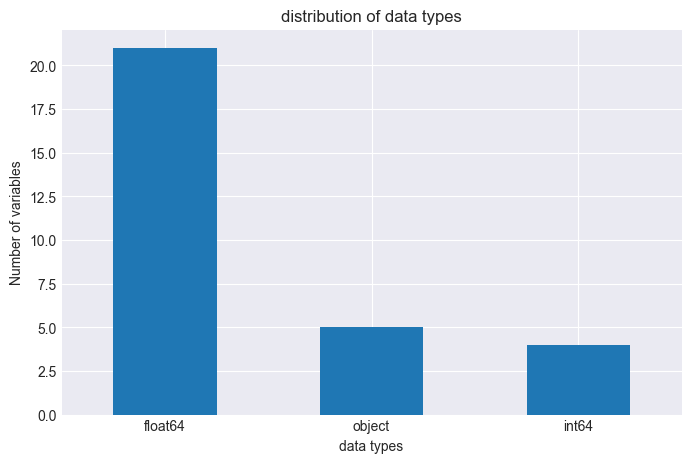

In [9]:

dtype_counts = train_df.dtypes.value_counts()

print(dtype_counts)

plt.figure(figsize=(8, 5))
dtype_counts.plot(kind='bar')

plt.title('distribution of data types')
plt.xlabel('data types')
plt.ylabel('Number of variables')
plt.xticks(rotation=0)  
plt.show()

In [10]:
train_df.describe().T

,count,mean,std,min,25%,50%,75%,max
fiscal_year,11828.0,2.019495e+03,1.116482e+00,2.018000e+03,2.018000e+03,2.019000e+03,2.020000e+03,2.021000e+03
ateco_sector,11828.0,4.582770e+01,1.667718e+01,1.000000e+01,4.100000e+01,4.600000e+01,5.600000e+01,8.200000e+01
years_in_business,11828.0,3.517940e+01,1.990809e+01,0.000000e+00,1.800000e+01,3.500000e+01,5.200000e+01,7.100000e+01
total_fixed_assets,11828.0,1.029206e+09,6.120958e+09,1.267167e+06,7.319803e+07,1.905995e+08,5.398741e+08,2.548712e+11
current_assets,11828.0,1.438435e+09,6.873106e+09,1.278800e+06,1.244471e+08,3.125597e+08,8.387197e+08,2.512549e+11
total_assets,11828.0,2.467641e+09,1.248305e+10,2.545968e+06,2.087793e+08,5.212379e+08,1.394478e+09,5.061262e+11
shareholders_equity,11828.0,9.163141e+08,5.023564e+09,-3.330561e+09,7.070428e+07,1.815958e+08,5.022747e+08,1.956145e+11
total_debt,11828.0,1.551327e+09,7.724478e+09,1.839791e+06,1.294646e+08,3.264152e+08,8.795087e+08,3.105116e+11
short_term_debt,11828.0,8.534656e+08,4.360360e+09,8.985461e+05,6.925617e+07,1.744802e+08,4.777298e+08,1.699685e+11
long_term_debt,11828.0,6.978617e+08,3.493369e+09,9.412449e+05,5.666362e+07,1.462585e+08,3.960070e+08,1.405431e+11


### Fiscal years check:
The range of fiscal_year in train_dataset is correct: from 2018 to 2021

In [11]:
unique_id = train_df[id_col].nunique()
unique_id_percentage = unique_id/len(train_df[id_col])*100

print(f'unique IDs:{unique_id}')
print(f'unique id percentage:{unique_id_percentage}')

unique IDs:2999
unique id percentage:25.355089617855935


### unique IDs 
are ~ 25% of the dataset, this is means that every companies appear ~ 4 times (1 for each fiscal year)

In [12]:
def missing_summary(df):
    missing_values = df.isnull().sum()
    missing_pct = (missing_values / len(df)) * 100
    missing_df = pd.DataFrame({
        'Missing Count': missing_values,
        'Percentage': missing_pct,
        'd_type': df.dtypes
    })
    missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
    return missing_df




In [13]:
missing_train = missing_summary(train_df)
print("Missing Values train:")
print(missing_train)

Missing Values train:
                Missing Count  Percentage   d_type
revenue_change           2999   25.355090  float64
province                  919    7.769699   object
roe                        45    0.380453  float64
leverage                   45    0.380453  float64


## Missingness evaluation (task 1 EDA)
The target `revenue_change`'s missingness is allign with the provided documentation, we'll conduct further analysis to state the nature of this missingness.

The other missing values will be handle with a imputation strategy

In [14]:

agg_funcs = {
    'Total Rows': 'size',
    'Missing Count': lambda x: x.isnull().sum(),
    'Missing %': lambda x: (x.isnull().sum() / len(x)) * 100
}

missing_per_year = train_df.groupby(time_col)[target].agg(**agg_funcs)

print(missing_per_year)

             Total Rows  Missing Count   Missing %
fiscal_year                                       
2018               2961           2961  100.000000
2019               2979             38    1.275596
2020               2956              0    0.000000
2021               2932              0    0.000000


The missingness in `revenue_change` is mostly in 2018 this because the target is defined on the prevoius year observation, so since there's not 2017 data, the 2018 is all NaN. The year 2018 will be used to predict the `revenue_change` in 2019

In [15]:
panel = (train_df[[id_col,time_col]].drop_duplicates().sort_values([id_col,time_col]))

years_per_company = panel.groupby(id_col)[time_col].agg(
    n_years = 'nunique',
    min_year= 'min',
    max_year= 'max'
)

dist_n = years_per_company["n_years"].value_counts().sort_index()
dist_n_pct = (dist_n / dist_n.sum() * 100).round(2)

print("Distribution n_years per company:")
print(pd.DataFrame({"count": dist_n, "pct": dist_n_pct}))

# 2) Gap check 
def has_gap(years: pd.Series) -> bool:
    yrs = np.sort(years.unique())
    return (np.diff(yrs) > 1).any()

gap_flag = panel.groupby(id_col)[time_col].apply(has_gap)
print(f"\nCompanies with temporal gaps: {int(gap_flag.sum())} ({gap_flag.mean()*100:.2f}%)")

has_2018 = panel.groupby(id_col)[time_col].apply(lambda s: 2018 in set(s))
print(f"\ncompanies with 2018 records: {int(has_2018.sum())} | without 2018 recors: {int((~has_2018).sum())}")

start_dist = years_per_company["min_year"].value_counts().sort_index()
end_dist = years_per_company["max_year"].value_counts().sort_index()
print("\nDistribution min_year (start):")
print(start_dist)
print("\nDistribution max_year (end):")
print(end_dist)

mask_2019_missing = (train_df[time_col] == 2019) & (train_df[target].isna())
missing_2019_companies = set(train_df.loc[mask_2019_missing, id_col])
if len(missing_2019_companies) > 0:
    share_without_2018 = (~has_2018.loc[list(missing_2019_companies)]).mean() * 100
    print(f"\n2019 target-missing rows: {mask_2019_missing.sum()}")
    print(f"Companies involved: {len(missing_2019_companies)}")
    print(f"% companies without 2018: {share_without_2018:.2f}%")


Distribution n_years per company:
         count    pct
n_years              
1           20   0.67
2           24   0.80
3           60   2.00
4         2895  96.53

Companies with temporal gaps: 0 (0.00%)

companies with 2018 records: 2961 | without 2018 recors: 38

Distribution min_year (start):
min_year
2018    2961
2019      38
Name: count, dtype: int64

Distribution max_year (end):
max_year
2018      20
2019      23
2020      24
2021    2932
Name: count, dtype: int64

2019 target-missing rows: 38
Companies involved: 38
% companies without 2018: 100.00%


## Panel Completeness (Train 2018–2021) — Key Findings

- **Near-balanced firm-year panel:** 2,999 unique companies across 11,828 rows (~3.94 rows/company).
- **Years per company distribution:**
  - 4 years: **2,895 companies (96.53%)**
  - 3 years: **60 (2.00%)**
  - 2 years: **24 (0.80%)**
  - 1 year: **20 (0.67%)**
- **No temporal gaps:** **0 companies (0.00%)** show missing intermediate years (when present, fiscal years are consecutive).
- **2018 coverage:**
  - Companies **with** 2018 records: **2,961**
  - Companies **without** 2018 records: **38**
  - `min_year` distribution: **2018 → 2,961**, **2019 → 38**
- **End-year distribution (`max_year`):**
  - 2018 → 20, 2019 → 23, 2020 → 24, 2021 → 2,932
- **Target missingness in 2019 is fully explained by missing history:**
  - 2019 `revenue_change` missing rows: **38**
  - Companies involved: **38**
  - **100%** of these companies **lack 2018 history**, meaning `revenue_change_2019` is not computable (no t−1 value).

**Implication:** Lag features based on `shift(1)` are highly reliable given the consecutive-year structure; first-observation cases (no prior year) are rare and can be handled via missing flags / `is_first_observation`.


Task 2: target distribution

In [31]:

def p25(x): return x.quantile(0.25)
def p75(x): return x.quantile(0.75)
def p90(x): return x.quantile(0.90)
def p95(x): return x.quantile(0.95)
def p99(x): return x.quantile(0.99)


tmp = train_df[[time_col, target]].copy()

metrics = tmp.groupby(time_col)[target].agg([
    'count', 
    'mean', 
    'median', 
    p25, 
    p75, 
    p90, 
    p95, 
    p99
])

# Opzionale: arrotondamento per leggibilità

print(metrics.round(2))

             count   mean  median    p25     p75     p90      p95      p99
fiscal_year                                                               
2018             0    NaN     NaN    NaN     NaN     NaN      NaN      NaN
2019          2941  396.5    1.82 -68.38  242.26  872.97  1753.54  6787.59
2020          2956  475.0    0.34 -69.50  231.29  895.66  1722.46  7079.24
2021          2932  488.8    7.50 -67.35  240.05  884.68  1767.23  5181.84


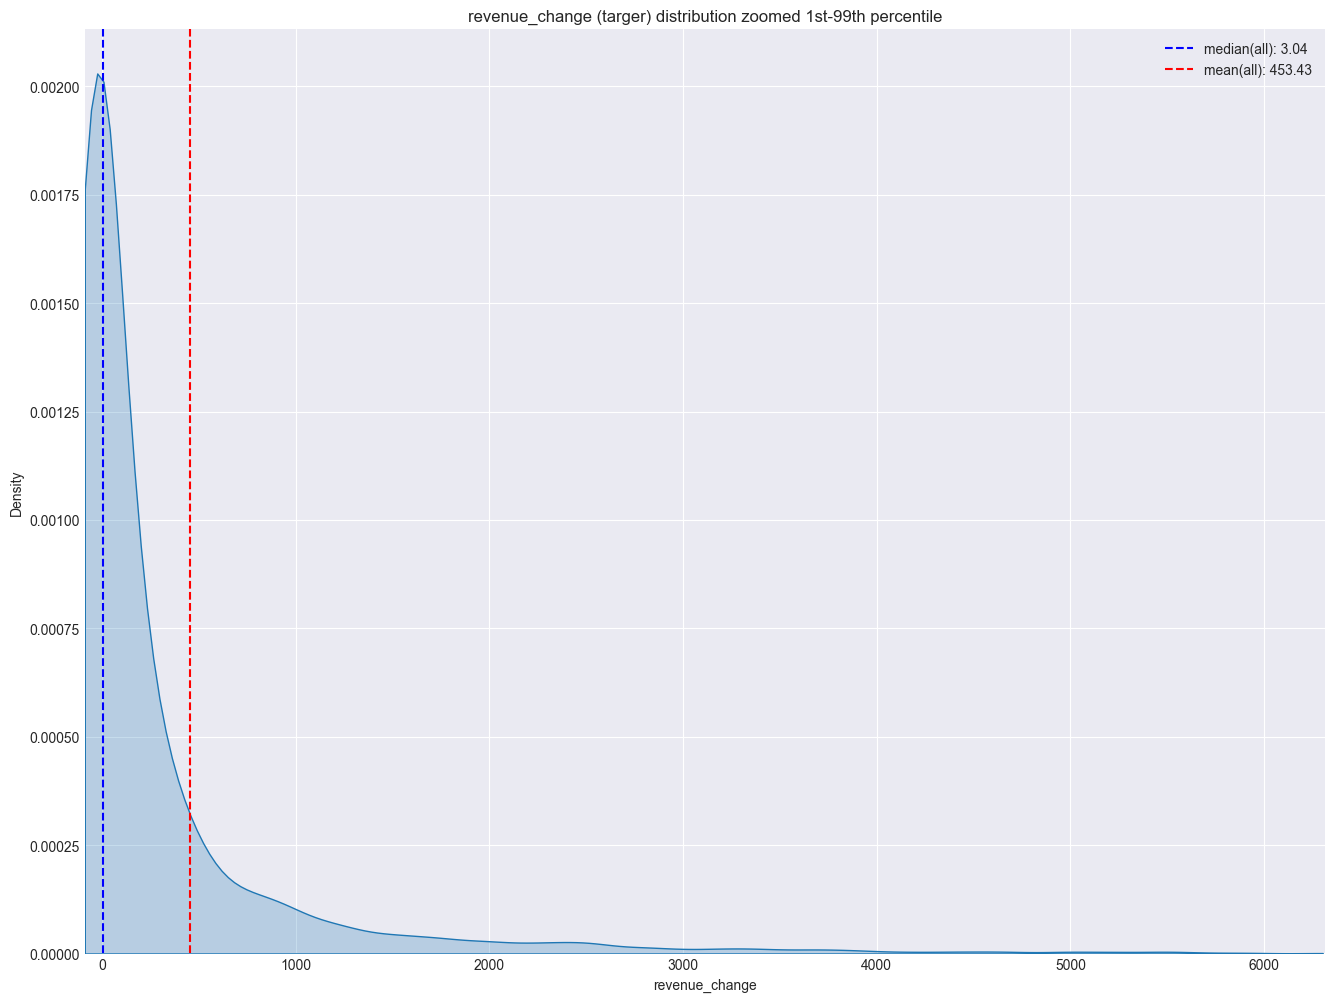

In [32]:
y = train_df[target].dropna().copy()
r_low, r_high = y.quantile([0.1, 0.99])
y_core = y[(y >= r_low) & (y <= r_high)]

plt.figure(figsize=(16,12))
sns.kdeplot(x=y_core, fill=True, cut=0)
plt.axvline(y.median(), color="blue", linestyle="--", label=f"median(all): {y.median():.2f}")
plt.axvline(y.mean(),   color="red",  linestyle="--", label=f"mean(all): {y.mean():.2f}")
plt.xlim(r_low, r_high)
plt.title('revenue_change (targer) distribution zoomed 1st-99th percentile')
plt.legend()
plt.show()

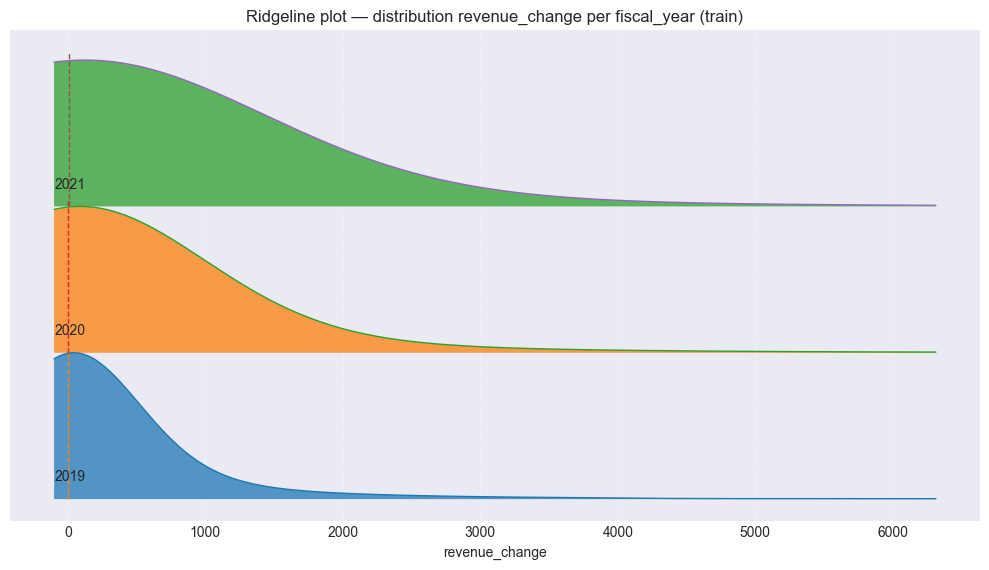

In [ ]:
df = train_df[np.isfinite(train_df["revenue_change"])].copy()

years = sorted(df["fiscal_year"].unique())

x_low, x_high = np.percentile(df["revenue_change"], [0, 99])
x = np.linspace(x_low, x_high, 600)

fig, ax = plt.subplots(figsize=(10, 1.6 * len(years) + 1))
gap = 1.0

for i, y in enumerate(years):
    vals = df.loc[df["fiscal_year"] == y, "revenue_change"].to_numpy()
    vals = vals[np.isfinite(vals)]   

    
    if len(vals) < 10 or np.std(vals) == 0:
        
        med = np.median(vals) if len(vals) else np.nan
        offset = i * gap
        if np.isfinite(med):
            ax.plot([med, med], [offset, offset + 0.8], linestyle="--", linewidth=1.2)
            ax.text(x_low, offset + 0.1, str(y), va="bottom", ha="left")
        continue

    kde = gaussian_kde(vals)
    dens = kde(x)
    dens = dens / dens.max()

    offset = i * gap
    ax.fill_between(x, offset, offset + dens, alpha=0.75)
    ax.plot(x, offset + dens, linewidth=1.0)

    med = np.median(vals)
    ax.plot([med, med], [offset, offset + 1.05], linestyle="--", linewidth=1.0)

    ax.text(x_low, offset + 0.1, str(y), va="bottom", ha="left")

ax.set_title("Ridgeline plot — distribution revenue_change per fiscal_year (train)")
ax.set_xlabel("revenue_change")
ax.set_yticks([])
ax.grid(axis="x", linestyle=":", linewidth=0.6, alpha=0.7)
plt.tight_layout()
plt.show()

Task 3 (target transform)


3.	TARGET DISTRIBUTION — HEAVY-TAIL VIEW (TRANSFORM-FRIENDLY)

The target variable `revenue_change` is defined as a "year over year" percentage change. Its distribution is often heavy-tailed: extreme values can arise not only from large absolute changes in revenue, but also from very small prior-year values in the denominator. To obtain a readable view of the full distribution while preserving sign information, we apply the signed-log transform:

$$
y_{\mathrm{slog}} = \mathrm{sign}(y)\,\log\left(1 + \left|y\right|\right)
$$

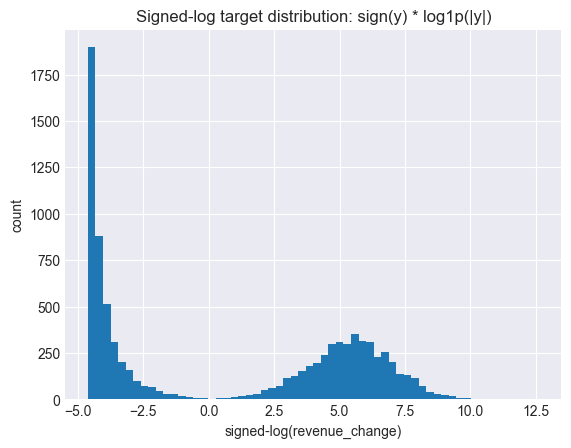

count    8829.000000
mean        0.771457
std         4.861886
min        -4.614526
1%         -4.601006
5%         -4.558875
50%         1.396245
95%         7.471273
99%         8.750574
max        12.618604
Name: revenue_change, dtype: float64

In [49]:
y = df[target].dropna().copy()
# Signed-log transform: preserves the sign while compressing extreme magnitudes
y_slog = np.sign(y) * np.log1p(np.abs(y))

plt.figure()
plt.hist(y_slog, bins=60)
plt.title("Signed-log target distribution: sign(y) * log1p(|y|)")
plt.xlabel("signed-log(revenue_change)")
plt.ylabel("count")
plt.show()

# Numeric evidence (original scale)
y_slog.describe(percentiles=[0.01, 0.05, 0.50, 0.95, 0.99])

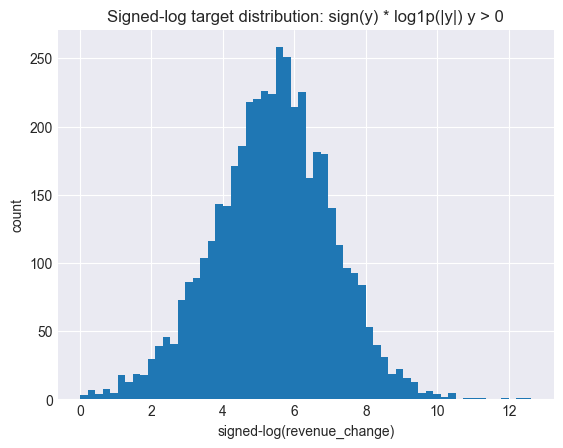

In [ ]:

y_pos = y[y > 0]
# Signed-log transform: preserves the sign while compressing extreme magnitudes
y_slog_pos = np.sign(y_pos) * np.log1p(np.abs(y_pos))

plt.figure()
plt.hist(y_slog_pos, bins=60)
plt.title("Signed-log target distribution: sign(y) * log1p(|y|) y > 0")
plt.xlabel("signed-log(revenue_change)")
plt.ylabel("count")
plt.show()


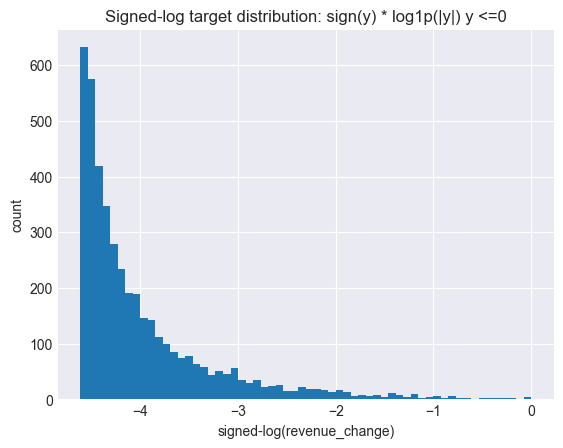

In [ ]:

y_neg = y[y <= 0]

y_slog_neg = np.sign(y_neg) * np.log1p(np.abs(y_neg))

plt.figure()
plt.hist(y_slog_neg, bins=60)
plt.title("Signed-log target distribution: sign(y) * log1p(|y|) y <=0")
plt.xlabel("signed-log(revenue_change)")
plt.ylabel("count")
plt.show()


The overall signed-log distribution looks bimodal due to the mixture of negative and positive outcomes; within each sign the distribution is largely unimodal.

In [60]:
tmp = train_df[(train_df[target].notna()) & (train_df[time_col] > 2018)].copy()

summary = tmp.groupby(time_col).agg(
    n_total=(target, "size"),
    n_neg=(target, lambda s: (s < 0).sum()),
)
summary["pct_neg"] = (summary["n_neg"] / summary["n_total"] * 100).round(2)

summary


,n_total,n_neg,pct_neg
fiscal_year,,,
2019,2941,1459,49.61
2020,2956,1474,49.86
2021,2932,1427,48.67


## Signed-log target transform — Assumptions & Modeling Risks 

### Transform definition
We transform the target `revenue_change` using:

$$
y_{\mathrm{slog}} = \mathrm{sign}(y)\,\log\left(1 + \left|y\right|\right)
$$

and invert predictions with:

$$
\hat{y} = \mathrm{sign}\left(\hat{y}_{\mathrm{slog}}\right)\left(\exp\left(\left|\hat{y}_{\mathrm{slog}}\right|\right)-1\right)
$$

---

## Assumptions (explicit)

### A1) Target is real-valued with meaningful sign
- Positive values mean growth, negative values mean contraction.
- Preserving sign is important for business interpretation (growth vs decline).

### A2) Extreme magnitudes are partly “scale artifacts”
- Very large `revenue_change` values may arise from:
  - genuine large changes, and/or
  - small prior-year denominators (near-zero `production_value_{t-1}`).
- Compressing magnitudes is desirable to prevent a few extreme points from dominating learning.

### A3) We care about stability more than perfect fidelity on extremes
- The transform prioritizes learning signal in the bulk of the distribution.
- Errors on extremely rare events are expected to be less learnable with available features.

### A4) Model can be trained on transformed space without leakage
- The transform is deterministic and does not use future information.
- All preprocessing (imputation/encoding/scaling) is fit on train-fold only and applied to val/test.

### A5) Evaluation must remain on the original business scale
- The challenge metric (and stakeholders) care about `revenue_change` in original units.
- Therefore: train on $y_{\mathrm{slog}}$, evaluate on inverted predictions in original $y$.

---

## Key model risks / criticalities

### R1) Boundary mass on the negative side (near -100%)
- If `revenue_change` is bounded near -100%, many negative observations can concentrate near this boundary.
- In signed-log space, values near -100% map around $-\log(1+100)$, creating a dense region.
**Implication:** the model may struggle to distinguish between “very negative” values (e.g., -80% vs -99%) because they are compressed into a narrow range.

**Mitigation:**
- Report errors separately for $y < 0$ vs $y \ge 0$.
- Consider a simple flag later (Task 5): `is_low_prev_production_value`.

---

### R2) Apparent bimodality is a mixture of signs (two populations)
- The overall transformed distribution can look bimodal because it mixes:
  - a negative contraction population and
  - a positive growth population.
**Implication:** a single regressor may learn a “central compromise” and underperform on one side if the mechanisms differ.

**Mitigation:**
- Segment-level evaluation: metrics on $y<0$ and $y>0$.
- Error analysis for extremes (top 1% $|y|$) vs core (p1–p99).

---

### R3) Heteroskedasticity and asymmetric business costs
- Even after transform, error variance may differ across regimes (negative vs positive, firm size, sectors).
**Implication:** RMSE alone can be misleading.

**Mitigation:**
- Primary: RMSE on original scale (as required).
- Secondary: MAE + Directional Accuracy (sign correctness).
- Optional reporting: “core RMSE” on p1–p99 subset.

---

### R4) Bias introduced by inverse transform (Jensen’s inequality)
- Training in log space and then inverting can bias predictions on the original scale,
  especially for high-variance regions (extremes).
**Implication:** the model may underpredict extreme positive spikes after inversion.

**Mitigation:**
- Accept as trade-off for stability.
- Document as limitation; quantify performance on extreme subset.

---

### R5) Metrics can be dominated by rare extremes on original scale
- Even with transformed training, evaluation on original scale (RMSE) can still be driven by rare outliers.
**Implication:** model ranking can be sensitive to a handful of points.

**Mitigation:**
- Always accompany RMSE with MAE and a “core RMSE” narrative for interpretability.
- Keep a dedicated “extreme cases” error analysis section.

---

### R6) Transform does not fix root-cause outliers (denominator effects)
- If extremes are driven by near-zero `production_value_{t-1}` or structural events (M&A/perimeter changes),
  the transform only reduces their influence; it does not make them predictable.
**Implication:** there is an irreducible error floor for such events.

**Mitigation:**
- Task 5: validate denominator mechanism with `production_value_lag1`.
- Add simple missing/low-denominator flags rather than complex mixture models.


4.	TEMPORAL DRIFT IN TARGET (2019–2020–2021) (COVID V-SHAPE)

We evaluate whether `revenue_change` exhibits a year-dependent shift in distribution, focusing on fiscal years 2019, 2020 and 2021.
We provide:
1. A year-level summary table with count, mean, median and tail percentiles (p95, p99).
2. A boxplot by year

ATTENTION: for the boxplot only, we clip values to the 1%–99% range to improve readability. This is a visualization convenience and must not be interpreted as removing outliers from the dataset.

In [ ]:
years = [2019, 2020, 2021]
df_3y = df.loc[df[time_col].isin(years), [time_col, target]].dropna().copy()

summary = (
    df_3y.groupby(time_col)[target]
    .agg(
        n="count",
        mean="mean",
        p1 = lambda s: s.quantile(0.01),
        p5 = lambda s: s.quantile(0.05),
        median="median",
        IQR =  lambda s: s.quantile(0.75) - s.quantile(0.25),
        p95=lambda s: s.quantile(0.95),
        p99=lambda s: s.quantile(0.99),
    )
    .reset_index()
    .sort_values(time_col)
)



,fiscal_year,n,mean,p1,p5,median,IQR,p95,p99
0,2019,2941,396.495774,-98.6280,-94.3500,1.820,310.6400,1753.5400,6787.5900
1,2020,2956,475.004239,-98.3125,-93.8525,0.340,300.7900,1722.4625,7079.2430
2,2021,2932,488.801917,-98.8207,-95.1425,7.495,307.4025,1767.2320,5181.8368


In [83]:

summary_fmt = summary.copy()

# round numeric columns
num_cols = ["mean", "median", "p1", "p5", "IQR", "p95", "p99"]
summary_fmt[num_cols] = summary_fmt[num_cols].round(2)

# ensure n is int
summary_fmt["n"] = summary_fmt["n"].astype(int)

# pretty display (Jupyter)
summary_fmt.style.format({
    "n": "{:,}",
    "mean": "{:,.2f}",
    "median": "{:,.2f}",
    "p1" : "{:,.2f}",
    "p5" : "{:,.2f}",
    "IQR": "{:,.2f}",
    "p95": "{:,.2f}",
    "p99": "{:,.2f}",
}).set_caption("Revenue_change drift summary by fiscal_year (2019–2021)")


,fiscal_year,n,mean,p1,p5,median,IQR,p95,p99
0,2019,"2,941",396.50,-98.63,-94.35,1.82,310.64,"1,753.54","6,787.59"
1,2020,"2,956",475.00,-98.31,-93.85,0.34,300.79,"1,722.46","7,079.24"
2,2021,"2,932",488.80,-98.82,-95.14,7.50,307.40,"1,767.23","5,181.84"


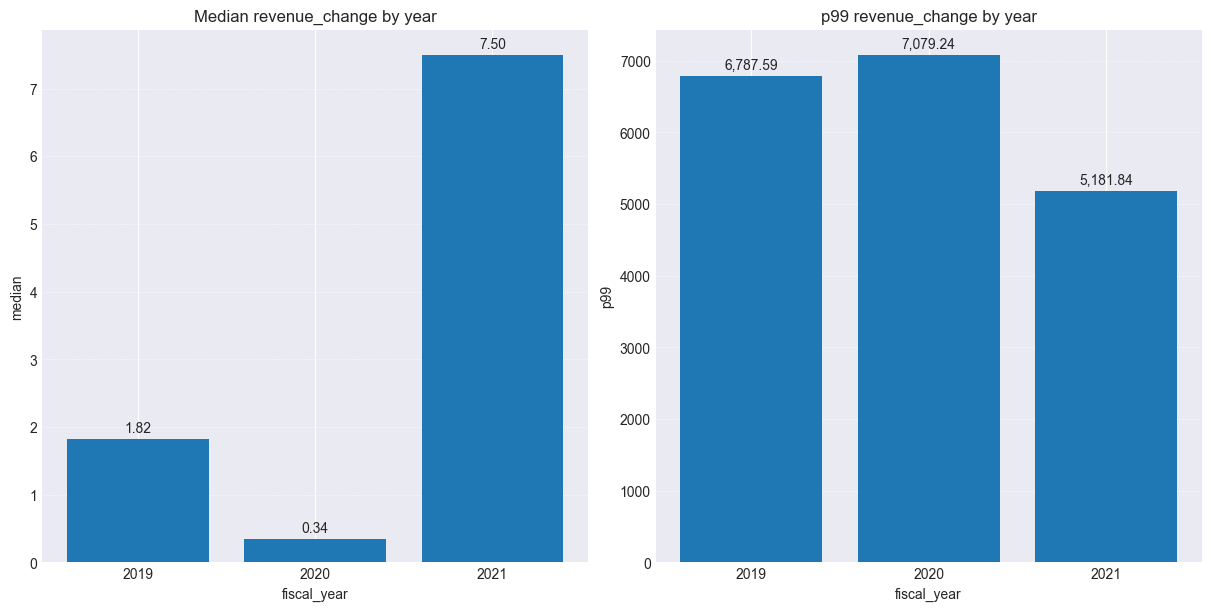

In [80]:

summary_sorted = summary.sort_values("fiscal_year").copy()
x = summary_sorted["fiscal_year"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)

# Chart 1: Median 
bars0 = axes[0].bar(x, summary_sorted["median"])
axes[0].set_title("Median revenue_change by year")
axes[0].set_xlabel("fiscal_year")
axes[0].set_ylabel("median")
axes[0].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

# value labels
for b in bars0:
    h = b.get_height()
    axes[0].annotate(f"{h:,.2f}",
                     (b.get_x() + b.get_width()/2, h),
                     ha="center", va="bottom",
                     xytext=(0, 3), textcoords="offset points")

# Chart 2: p99 
bars1 = axes[1].bar(x, summary_sorted["p99"])
axes[1].set_title("p99 revenue_change by year")
axes[1].set_xlabel("fiscal_year")
axes[1].set_ylabel("p99")
axes[1].grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.6)

# value labels
for b in bars1:
    h = b.get_height()
    axes[1].annotate(f"{h:,.2f}",
                     (b.get_x() + b.get_width()/2, h),
                     ha="center", va="bottom",
                     xytext=(0, 3), textcoords="offset points")

plt.show()


## Temporal drift in `revenue_change` (2019–2021) — Findings

### Business interpretation
- **Typical firm outcome shifts:** the **median** dips in 2020 and rebounds in 2021, suggesting a mild contraction/recovery pattern in the “typical” company (median: **1.82 → 0.34 → 7.50**).
- **Extreme upside changes:** the **top 1%** outcomes are more pronounced in 2019–2020 and **drop in 2021**, indicating fewer/less extreme “exceptional growth” events in 2021 (p99: **6,787.59 → 7,079.24 → 5,181.84**).
- **Core spread and downside tail are stable:** **IQR** and **p95** remain broadly stable, and the **downside extremes** (p1, p5) are also stable, suggesting the worst contractions did not materially deepen across years.

### Modeling implications
- **Time-aware validation is justified:** the shift in central tendency (median) indicates mild **distribution shift**, so 2021 is not fully i.i.d. with 2019–2020.
- **RMSE sensitivity to extremes:** changes in **p99** imply that a few extreme observations can disproportionately affect RMSE and perceived performance across years.
- **Robust training remains appropriate:** given heavy tails and tail instability, we keep training on the **signed-log target** and evaluate on the original scale, complementing RMSE with secondary diagnostics (e.g., MAE / directional accuracy and core-range checks).


In [16]:
# Target variable analysis
# TODO: Uncomment the relevant section for your challenge

# For Challenge 1: Bankruptcy Prediction
# print("\nBankruptcy Distribution:")
# print(train_df['bankruptcy_next_year'].value_counts())
# print(f"\nBankruptcy rate: {train_df['bankruptcy_next_year'].mean():.2%}")

# For Challenge 2: Financial Health Classification
# print("\nFinancial Health Distribution:")
# print(train_df['financial_health_class'].value_counts().sort_index())
# print("\nPercentages:")
# print(train_df['financial_health_class'].value_counts(normalize=True).sort_index())

# For Challenge 3: Revenue Forecasting
# print("\nRevenue Change Statistics:")
# print(train_df['revenue_change'].describe())
# print(f"\nMissing revenue_change: {train_df['revenue_change'].isnull().sum()}")

### Exploratory Data Analysis (EDA)

Create visualizations to understand the data better.

**Key Insights from EDA:**

TODO: Document your key findings
- 
- 
- 

## 3. Data Preprocessing

Handle missing values, outliers, and prepare data for modeling.

In [17]:
# Create a copy for preprocessing
df_processed = train_df.copy()

# TODO: Handle missing values
# - Decide on imputation strategy (median, mean, by group, etc.)
# - Document your rationale

# TODO: Handle outliers
# - Identify outliers (IQR, winsorization, etc.)
# - Decide on treatment strategy

# TODO: Encode categorical variables
# - One-hot encoding, label encoding, etc.

print("Preprocessing complete!")

Preprocessing complete!


In [18]:
# Train/Validation split
# IMPORTANT: Use temporal split, not random!

# For Challenges 1 & 2:
# train_years = [2018, 2019, 2020]
# val_year = 2021

# For Challenge 3 (time series):
# train_years = [2018, 2019]
# val_year = 2020
# test_year = 2021

# TODO: Implement temporal split
# df_train = df_processed[df_processed['fiscal_year'].isin(train_years)]
# df_val = df_processed[df_processed['fiscal_year'] == val_year]

print("Train/validation split complete!")

Train/validation split complete!


In [19]:
# Feature scaling
# IMPORTANT: Fit scaler on training data only!

from sklearn.preprocessing import StandardScaler, RobustScaler

# TODO: Choose and apply scaler
# scaler = StandardScaler()  # or RobustScaler() for outlier resistance
# X_train_scaled = scaler.fit_transform(X_train)
# X_val_scaled = scaler.transform(X_val)

print("Feature scaling complete!")

Feature scaling complete!


## 4. Feature Engineering

Create new features based on domain knowledge.

In [20]:
# TODO: Engineer features
# Ideas:
# - Financial ratios (if not already present)
# - Year-over-year changes (growth rates)
# - Interaction features
# - Altman Z-Score or similar bankruptcy models
# - Sector-relative features (company vs sector average)
# - Temporal features (trends, volatility)

# Example: Year-over-year change
# df_processed = df_processed.sort_values(['company_id', 'fiscal_year'])
# df_processed['roe_yoy_change'] = df_processed.groupby('company_id')['roe'].diff()

print("Feature engineering complete!")
print(f"Total features: {df_processed.shape[1]}")

Feature engineering complete!
Total features: 30


**Engineered Features:**

TODO: List and explain your engineered features
1. 
2. 
3. 

## 5. Model Development

Train multiple models and compare performance.

In [21]:
#
#  Import models
#from sklearn.linear_model import LogisticRegression, LinearRegression, Ridge
#from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
#from sklearn.metrics import (
 #   classification_report, confusion_matrix, 
  #  f1_score, roc_auc_score, accuracy_score,
   # mean_squared_error, mean_absolute_error, r2_score
#)
#from xgboost import XGBClassifier, XGBRegressor

# For handling class imbalance (Challenges 1 & 2)
#from imblearn.over_sampling import SMOTE
#from sklearn.utils.class_weight import compute_class_weight

print("Model libraries imported!")

Model libraries imported!


In [22]:
# TODO: Prepare X and y
# feature_cols = [...]  # List your feature columns
# target_col = 'bankruptcy_next_year'  # or 'financial_health_class' or 'revenue_change'

# X_train = df_train[feature_cols]
# y_train = df_train[target_col]
# X_val = df_val[feature_cols]
# y_val = df_val[target_col]

print("Data prepared for modeling!")

Data prepared for modeling!


### Baseline Model

In [23]:
# TODO: Train baseline model
# For classification: Logistic Regression
# For regression: Linear Regression

# Example for Challenge 1 (Bankruptcy):
# baseline_model = LogisticRegression(random_state=RANDOM_STATE, class_weight='balanced')
# baseline_model.fit(X_train_scaled, y_train)
# y_pred_baseline = baseline_model.predict(X_val_scaled)

# print("Baseline Model Performance:")
# print(classification_report(y_val, y_pred_baseline))
# print(f"F1-Score: {f1_score(y_val, y_pred_baseline):.4f}")

### Advanced Models

In [24]:
# TODO: Train multiple models
# - Random Forest
# - XGBoost
# - Gradient Boosting
# - etc.

# For classification with imbalance, consider:
# - SMOTE oversampling
# - Class weights
# - Threshold tuning

# Example for Random Forest with SMOTE:
# smote = SMOTE(random_state=RANDOM_STATE)
# X_train_resampled, y_train_resampled = smote.fit_resample(X_train_scaled, y_train)

# rf_model = RandomForestClassifier(
#     n_estimators=100,
#     max_depth=10,
#     random_state=RANDOM_STATE
# )
# rf_model.fit(X_train_resampled, y_train_resampled)

print("Advanced models trained!")

Advanced models trained!


In [25]:
# TODO: Hyperparameter tuning
# Use GridSearchCV or RandomizedSearchCV

from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Example:
# param_grid = {
#     'n_estimators': [50, 100, 200],
#     'max_depth': [5, 10, 15],
#     'min_samples_split': [2, 5, 10]
# }

# grid_search = GridSearchCV(
#     RandomForestClassifier(random_state=RANDOM_STATE),
#     param_grid,
#     cv=StratifiedKFold(n_splits=5),
#     scoring='f1',
#     n_jobs=-1
# )
# grid_search.fit(X_train_scaled, y_train)
# best_model = grid_search.best_estimator_

print("Hyperparameter tuning complete!")

Hyperparameter tuning complete!


## 6. Model Evaluation

Compare models and select the best one.

In [26]:
# TODO: Create model comparison table
# Compare all models on validation set using appropriate metrics

# For Challenge 1: F1-Score, AUC-ROC, Precision, Recall
# For Challenge 2: Weighted F1, Macro F1, Accuracy, Confusion Matrix
# For Challenge 3: RMSE, MAE, MAPE, R², Directional Accuracy

# Example comparison:
# models_comparison = pd.DataFrame({
#     'Model': ['Baseline', 'Random Forest', 'XGBoost'],
#     'F1-Score': [...],
#     'AUC-ROC': [...],
#     'Precision': [...],
#     'Recall': [...]
# })
# print(models_comparison)

In [27]:
# TODO: Confusion Matrix (for classification)
# from sklearn.metrics import ConfusionMatrixDisplay

# ConfusionMatrixDisplay.from_estimator(best_model, X_val_scaled, y_val)
# plt.title('Confusion Matrix - Best Model')
# plt.show()

In [28]:
# TODO: ROC Curve (for binary classification)
# from sklearn.metrics import RocCurveDisplay

# RocCurveDisplay.from_estimator(best_model, X_val_scaled, y_val)
# plt.title('ROC Curve - Best Model')
# plt.show()

**Model Selection:**

TODO: Justify your final model choice
- 
- 

## 7. Interpretation and Business Insights

Explain the model and extract business value.

In [29]:
# TODO: Feature Importance
# For tree-based models, use built-in feature importance
# For other models, consider SHAP values

# Example:
# feature_importance = pd.DataFrame({
#     'feature': feature_cols,
#     'importance': best_model.feature_importances_
# }).sort_values('importance', ascending=False)

# plt.figure(figsize=(10, 6))
# plt.barh(feature_importance['feature'][:15], feature_importance['importance'][:15])
# plt.xlabel('Importance')
# plt.title('Top 15 Most Important Features')
# plt.gca().invert_yaxis()
# plt.tight_layout()
# plt.show()

In [30]:
# TODO: Error Analysis
# - Which cases does the model misclassify/mispredicts?
# - Are there patterns in the errors?
# - How do errors vary by sector, size, region, etc.?

# Example:
# errors_df = df_val.copy()
# errors_df['prediction'] = y_pred
# errors_df['error'] = (errors_df['prediction'] != errors_df[target_col])

# print("Error rate by sector:")
# print(errors_df.groupby('ateco_sector')['error'].mean().sort_values(ascending=False))

**Business Insights:**

TODO: Translate technical findings into business language

**Key Risk Factors** (for bankruptcy/health challenges):
1. 
2. 
3. 

**Revenue Drivers** (for forecasting challenge):
1. 
2. 
3. 

**Actionable Recommendations:**
- 
- 
- 

## 8. Conclusions and Future Work

Summarize findings and discuss limitations.

**Summary:**

TODO: Summarize your work
- 
- 

**Performance vs Targets:**

TODO: Compare your results to challenge targets
- My F1-Score: [X.XX] vs Target: [0.55-0.70]
- ...

**Model Limitations:**

TODO: Discuss limitations honestly
1. 
2. 
3. 

**Future Improvements:**

TODO: What would you do with more time?
1. 
2. 
3. 

**Lessons Learned:**

TODO: Reflect on the experience
- 
- 

---

## Final Checklist

Before submitting, verify:

- [ ] All code cells execute without errors
- [ ] Markdown cells explain each step clearly
- [ ] Visualizations are clear and labeled
- [ ] Feature importance is analyzed
- [ ] Error analysis is performed
- [ ] Business insights are provided
- [ ] Model limitations are discussed
- [ ] Code is well-commented
- [ ] Results meet or exceed minimum performance targets
- [ ] No data leakage (temporal split, proper scaling, etc.)
- [ ] Citations for any external code/resources

**Good luck with your challenge!** 🚀